# CS3244 Group 17 Project: IMDb Spoiler Detection from Movie Reviews

This notebook focuses on the model-training stage for binary spoiler classification on IMDb reviews. It loads preprocessed artifact splits and precomputed feature sets to tune, train, and evaluate classifiers.

Workflow: setup and artifact loading, model training and hyperparameter tuning, model evaluation.

## 1. Setup and Data Loading

In [9]:
# imports
import pandas as pd
import numpy as np
import joblib, pickle, re, html, unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from pathlib import Path
from scipy import sparse
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm

In [ ]:
# # Read review dataset
# df = pd.read_json("IMDB_reviews.json", lines=True)

## 2. Data Cleaning and Preprocessing
This section performs cleaning and preprocessing to build the master dataset used across all downstream modeling steps.

In [ ]:
# # create master dataset
# df_master = df.copy()

In [ ]:
# # Remove duplicate reviews which have different label assigned to the same text
# conflicts = df_master.groupby("review_text")["is_spoiler"].nunique()
# conflicts = conflicts[conflicts > 1].index

# df_master = df_master[~df_master["review_text"].isin(conflicts)]

# # Remove exact duplicate reviews to avoid redundancy and data leakage
# df_master = df_master.drop_duplicates(subset=["review_text"])

# # Remove extremely short reviews that are likely low-information or noisy
# df_master = df_master[df_master["review_text"].str.len() > 25]

# # Remove extremely long reviews that may distort feature distributions and increase computational cost
# df_master = df_master[df_master["review_text"].str.len() < 10000]

# # Add review length as a feature due to strong correlation with spoiler labels
# df_master["length"] = df_master["review_text"].str.len()

# # Reset index after row removals to keep the cleaned dataset tidy and consistent
# df_master = df_master.reset_index(drop=True)

In [ ]:
# # Review date stored as object, convert to datetime
# df_master["review_date"] = pd.to_datetime(df_master["review_date"])

In [ ]:
# # Basic data cleaning function
# def basic_clean(text):
#     text = str(text) # Forces text to be a String
#     text = html.unescape(text) # Converts HTML to normal text
#     text = unicodedata.normalize("NFKC", text) # Normalizes unicode into a consistent canonical form
#     text = re.sub(r"<[^>]+>", " ", text) # Removes HTML tags 
#     text = text.lower() # Converts all text to lowercase
#     text = re.sub(r"\s+", " ", text) # Collapses all whitespace into a single space
#     text = text.strip() # Removes whitespace in front and behind of text
#     return text

In [ ]:
# # Clean "clean_text" in master dataframe
# df_master["clean_text"] = df_master["review_text"].apply(basic_clean)

## 3. Data Splitting
This notebook reuses the grouped movie-level train/test split and the artifact-specific train, validation, and fulltrain datasets created in the preprocessing notebook.
The commented cells below are kept only as reference for how those splits were originally constructed.

In [ ]:
# # Function for splitting data into training and testing sets
# def group_data_split(df, group_col="movie_id", test_size=0.2, random_state=42):
#     """
#     Split a dataframe into train and test sets using group-based splitting.

#     Parameters
#     ----------
#     df : pandas.DataFrame
#         Input dataframe.
#     group_col : str, default="movie_id"
#         Column used to define groups that must not be split across train and test.
#     test_size : float, default=0.2
#         Proportion of groups to place in the test set.
#     random_state : int, default=42
#         Random seed for reproducibility.

#     Returns
#     -------
#     df_train : pandas.DataFrame
#         Training subset.
#     df_test : pandas.DataFrame
#         Test subset.
#     """
#     gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

#     train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

#     df_train = df.iloc[train_idx].reset_index(drop=True)
#     df_test = df.iloc[test_idx].reset_index(drop=True)

#     return df_train, df_test

In [ ]:
# # Splitting data into training set and testing set (grouped by movie_id)
# df_train, df_test = group_data_split(
#     df_master, 
#     group_col="movie_id", 
#     test_size=0.2, 
#     random_state=42
# )

In [ ]:
# # Create Stratified Group K-Fold splits on the training set
# N_SPLITS = 5
# CV_SEED = 42
# cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# cv_splits = list(
#     cv.split(
#         df_train["clean_text"],
#         df_train["is_spoiler"],
#         groups=df_train["movie_id"],
#     )
# )
# print("Number of CV folds:", len(cv_splits))

Number of CV folds: 5


## 4. Model Training and Hyperparameter Tuning

This section uses a fixed artifact-based model-selection protocol to keep comparisons fair and avoid leakage.

- Each artifact stream provides a train split for fitting and a validation split for hyperparameter selection.
- Selected hyperparameters are then retrained on the corresponding `fulltrain` split.
- The held-out `df_test` split is reserved for final evaluation in Section 5.

For each model family, the workflow is:
1. Train on the artifact-specific train split (done in preprocessing)
2. Tune hyperparameters on the validation split.
3. Refit on the corresponding `fulltrain` split.
4. Evaluate once on the held-out test split in Section 5.

### 4.1 Shared Tuning Settings

All models in Section 4 select hyperparameters primarily by validation AUC using a shared tuning setup. The search ranges are defined once below for consistency, while feature-specific implementation details such as sparse versus dense preprocessing remain inside the individual model cells.

This subsection contains the shared scoring metric, fold count, random seed, and search ranges used during model selection. The fast-rerun fixed hyperparameters are separated into the next subsection.

In [25]:
SCORING_METRIC = "roc_auc"
N_SPLITS = 5
RANDOM_STATE = 42
CLASS_WEIGHT = "balanced"

LR_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
BERT_LR_C_GRID = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
LR_MAX_ITER = 2000

SVM_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
SVM_TOL = 1e-4
SVM_MAX_ITER = 3000
SVM_CALIBRATION_CV = 3
SVM_CALIBRATION_METHOD = "sigmoid"

DT_PARAM_GRID = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [10, 25, 50],
    "min_samples_leaf": [5, 10, 20],
    "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
}
DT_RANDOM_SEARCH_ITER = 10

NB_ALPHA_GRID = [0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
NB_THRESHOLD_GRID = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

### 4.2 Fast Rerun Settings

This subsection stores fixed hyperparameters from earlier CV results so repeated runs can skip tuning and go straight to refitting on the full training split.

Set `USE_FIXED_BEST_PARAMS = True` to use the saved values below when they are available. Leave a value as `None` if that model has not completed its first tuning run yet.

In [26]:
USE_FIXED_BEST_PARAMS = True

LR_TFIDF_FIXED_C = 0.3
LR_TFIDF_LEMMA_FIXED_C = 0.3
LR_BERT_FIXED_C = 10.0
SVM_TFIDF_FIXED_C = 0.03
SVM_TFIDF_LEMMA_FIXED_C = 0.03
SVM_BERT_FIXED_C = 3.0
DT_TFIDF_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
DT_TFIDF_LEMMA_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
DT_BERT_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
RF_TF_IDF_FIXED_PARAMS = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
RF_TF_IDF_LEMMA_FIXED_PARAMS = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
NB_TFIDF_FIXED_ALPHA = None
NB_TFIDF_FIXED_THRESHOLD = None

### 4.3 Feature Artifact Loading

Run the next cell to load both artifact streams (`artifacts_1` and `artifacts_2`) into memory, including train, validation, test, and fulltrain variants.
Helper functions are provided so later model sections can select which artifact stream to use while remaining backward compatible with existing calls.

In [ ]:
# Load artifact streams into memory for downstream model training
ARTIFACT_DIRS = {
    "artifacts_1": Path("artifacts_1"),
    "artifacts_2": Path("artifacts_2"),
}

def _safe_load_npy(path: Path):
    return np.load(path) if path.exists() else None

def _safe_load_npz(path: Path):
    return sparse.load_npz(path) if path.exists() else None

def _safe_load_joblib(path: Path):
    return joblib.load(path) if path.exists() else None

def _require(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact file: {path}")
    return path

def load_data_no_emb(folder: Path):
    
    if not path.exists():
        return None
        
    # Load main data
    with open(folder / "bert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    labels = data["labels"]
    review_ids = data["review_ids"]
    review_label_map = data["review_label_map"]
    
    return labels, review_ids, review_label_map

def load_artifact_bundle(artifact_name: str):
    if artifact_name not in ARTIFACT_DIRS:
        raise ValueError(f"Unknown artifact_name={artifact_name}. Expected one of {list(ARTIFACT_DIRS)}")

    artifact_dir = ARTIFACT_DIRS[artifact_name]
    if not artifact_dir.exists():
        raise FileNotFoundError(f"Artifact directory not found: {artifact_dir}")

    bundle = {"artifact_dir": artifact_dir}

    # Required labels
    bundle["labels_train"] = np.load(_require(artifact_dir / "labels_train.npy"))
    bundle["labels_val"] = np.load(_require(artifact_dir / "labels_val.npy"))
    bundle["labels_test"] = np.load(_require(artifact_dir / "labels_test.npy"))
    bundle["labels_fulltrain"] = np.load(_require(artifact_dir / "labels_fulltrain.npy"))

    # Required TF-IDF matrices
    bundle["X_tfidf_train"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_train.npz"))
    bundle["X_tfidf_val"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_val.npz"))
    bundle["X_tfidf_test"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_test.npz"))
    bundle["X_tfidf_fulltrain"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_fulltrain.npz"))
    bundle["X_tfidf_test_fulltrain"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_test_fulltrain.npz"))

    # Required TF-IDF + lemma matrices
    bundle["X_tfidf_lemma_train"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_lemma_train.npz"))
    bundle["X_tfidf_lemma_val"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_lemma_val.npz"))
    bundle["X_tfidf_lemma_test"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_lemma_test.npz"))
    bundle["X_tfidf_lemma_fulltrain"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_lemma_fulltrain.npz"))
    bundle["X_tfidf_lemma_test_fulltrain"] = sparse.load_npz(_require(artifact_dir / "X_tfidf_lemma_test_fulltrain.npz"))

    # Optional vectorizers
    bundle["tfidf_vectorizer"] = _safe_load_joblib(artifact_dir / "tfidf_vectorizer.joblib")
    bundle["tfidf_vectorizer_fulltrain"] = _safe_load_joblib(artifact_dir / "tfidf_vectorizer_fulltrain.joblib")
    bundle["tfidf_lemma_vectorizer"] = _safe_load_joblib(artifact_dir / "tfidf_lemma_vectorizer.joblib")
    bundle["tfidf_lemma_vectorizer_fulltrain"] = _safe_load_joblib(artifact_dir / "tfidf_lemma_vectorizer_fulltrain.joblib")

    return bundle

def load_all_artifacts():
    return {name: load_artifact_bundle(name) for name in ARTIFACT_DIRS}

ARTIFACT_STORE = load_all_artifacts()

for name, b in ARTIFACT_STORE.items():
    print(
        f"{name}: "
        f"train={b['X_tfidf_train'].shape}, "
        f"val={b['X_tfidf_val'].shape}, "
        f"test={b['X_tfidf_test'].shape}, "
        f"fulltrain={b['X_tfidf_fulltrain'].shape}"
    )

def load_cv_fold(fold_idx=None, artifact_name="artifacts_1"):
    # Backward-compatible adapter: returns train/val tensors from selected artifact stream.
    b = ARTIFACT_STORE[artifact_name]
    return {
        "y_train": b["labels_train"],
        "y_val": b["labels_val"],
        "X_tfidf_train": b["X_tfidf_train"],
        "X_tfidf_val": b["X_tfidf_val"],
        "X_tfidf_lemma_train": b["X_tfidf_lemma_train"],
        "X_tfidf_lemma_val": b["X_tfidf_lemma_val"],
    }

def load_full_train_test(artifact_name="artifacts_1", use_fulltrain=True):
    # Backward-compatible adapter: by default uses fulltrain (subset + val) for final retraining.
    b = ARTIFACT_STORE[artifact_name]
    if use_fulltrain:
        return {
            "y_train_full": b["labels_fulltrain"],
            "y_test": b["labels_test"],
            "X_tfidf_train_full": b["X_tfidf_fulltrain"],
            "X_tfidf_test": b["X_tfidf_test_fulltrain"],
            "X_tfidf_lemma_train_full": b["X_tfidf_lemma_fulltrain"],
            "X_tfidf_lemma_test": b["X_tfidf_lemma_test_fulltrain"],
            "X_bert_train_full": b["X_bert_train_full"],
            "X_bert_test": b["X_bert_test"],
        }

    return {
        "y_train_full": b["labels_train"],
        "y_test": b["labels_test"],
        "X_tfidf_train_full": b["X_tfidf_train"],
        "X_tfidf_test": b["X_tfidf_test"],
        "X_tfidf_lemma_train_full": b["X_tfidf_lemma_train"],
        "X_tfidf_lemma_test": b["X_tfidf_lemma_test"],
        "X_bert_train_full": b["X_bert_train_full"],
        "X_bert_test": b["X_bert_test"],
    }

def load_transformer_artifact_split(artifact_name: str, split_name: str, model_type: str):
    artifact_dir = ARTIFACT_DIRS[artifact_name]
    
    # Load metadata (always same)
    with open(artifact_dir / f"bert_window_data_{split_name}.pkl", "rb") as f:
        data = pickle.load(f)
    with open(artifact_dir / f"bert_windows_{split_name}.pkl", "rb") as f:
        windows = pickle.load(f)

    # Load embeddings differently depending on model
    if model_type == "sbert":
        X = np.load(artifact_dir / f"{split_name}/X_bert.npy")

    elif model_type == "roberta":
        X = np.load(artifact_dir / f"{split_name}/X_roberta.npy")

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return {
        "X": X,
        "windows": windows,
        "labels": np.asarray(data["labels"], dtype=np.int64),
        "review_ids": np.asarray(data["review_ids"], dtype=np.int64),
        "review_label_map": data["review_label_map"],
    }

def load_transformer_validation_splits(artifact_name="artifacts_1", model_type="sbert"):
    train = load_transformer_artifact_split(artifact_name, "train", model_type)
    val = load_transformer_artifact_split(artifact_name, "val", model_type)

    return {
        "X_train": train["X"],
        "y_train": train["labels"],
        "review_ids_train": train["review_ids"],
        "review_label_map_train": train["review_label_map"],

        "X_val": val["X"],
        "y_val": val["labels"],
        "review_ids_val": val["review_ids"],
        "review_label_map_val": val["review_label_map"],
    }
    
def load_transformer_fulltrain_test_splits(artifact_name="artifacts_1", model_type="sbert"):
    fulltrain = load_transformer_artifact_split(artifact_name, "fulltrain", model_type)
    test = load_transformer_artifact_split(artifact_name, "test", model_type)

    return {
        "X_train_full": fulltrain["X"],
        "y_train_full": fulltrain["labels"],
        "review_ids_train_full": fulltrain["review_ids"],
        "review_label_map_train_full": fulltrain["review_label_map"],

        "X_test": test["X"],
        "y_test": test["labels"],
        "review_ids_test": test["review_ids"],
        "review_label_map_test": test["review_label_map"],
    }

### 4.4 Logistic Regression

#### 4.4.1 TF-IDF

In [ ]:
from sklearn.linear_model import LogisticRegression

# Artifact-based workflow by subset stream:
# 1) train on the train split
# 2) tune on the validation split
# 3) retrain on the fulltrain split
# 4) evaluate on the test split

SUBSET_TO_ARTIFACT = {
    "subset 1": "artifacts_1",
    "subset 2": "artifacts_2",
}

subset_best_c = {}
subset_models = {}
subset_tuning_results = {}
subset_test_rows = []

for subset_name, artifact_name in SUBSET_TO_ARTIFACT.items():
    print(f"\n===== Logistic Regression TF-IDF | {subset_name} ({artifact_name}) =====")

    # Step 1 + 2: train on train split and tune with validation split
    cv_artifacts = load_cv_fold(artifact_name=artifact_name)
    X_train = cv_artifacts["X_tfidf_train"]
    X_val = cv_artifacts["X_tfidf_val"]
    y_train = cv_artifacts["y_train"]
    y_val = cv_artifacts["y_val"]

    tuning_rows = []
    for c_value in tqdm(LR_C_GRID, desc=f"{subset_name} C search", leave=False):
        model = LogisticRegression(
            C=c_value,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        tuning_rows.append(
            {
                "C": c_value,
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            }
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    subset_tuning_results[subset_name] = tuning_df
    best_c = float(tuning_df.loc[0, "C"])
    subset_best_c[subset_name] = best_c

    print(f"Best C for {subset_name}: {best_c}")
    display(tuning_df.rename(columns={"average_precision": "pr-auc"}))

    # Step 3: retrain on fulltrain split with best C
    full_artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = full_artifacts["X_tfidf_train_full"]
    y_train_full = full_artifacts["y_train_full"]
    X_test = full_artifacts["X_tfidf_test"]
    y_test = full_artifacts["y_test"]

    final_model = LogisticRegression(
        C=best_c,
        solver="saga",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    )
    final_model.fit(X_train_full, y_train_full)
    subset_models[subset_name] = final_model

    # Step 4: evaluate on test set
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    subset_test_rows.append(
        {
            "subset": subset_name,
            "recall": recall_score(y_test, y_test_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_test, y_test_prob >= 0.5),
            "f2": fbeta_score(y_test, y_test_prob >= 0.5, beta=2, zero_division=0),
            "auc": roc_auc_score(y_test, y_test_prob),
            "average_precision": average_precision_score(y_test, y_test_prob),
            "f1": f1_score(y_test, y_test_prob >= 0.5, zero_division=0),
            "precision": precision_score(y_test, y_test_prob >= 0.5, zero_division=0),
        }
    )

# Step 4 output: one row per subset, same metric family as current notebook
subset_test_metrics_df = pd.DataFrame(subset_test_rows)
metric_cols = ["recall", "accuracy", "f2", "auc", "average_precision", "f1", "precision"]
ordered_cols = ["subset"] + metric_cols

print("Test metrics by subset:")
display(subset_test_metrics_df[ordered_cols].rename(columns={"average_precision": "pr-auc"}).round(6))

# Step 6: average metrics across subset 1 and subset 2
avg_metrics_row = subset_test_metrics_df[metric_cols].mean().to_frame().T
avg_metrics_row.insert(0, "subset", "average")
print("Average test metrics across subsets:")
display(avg_metrics_row[ordered_cols].rename(columns={"average_precision": "pr-auc"}).round(6))

# Keep compatibility with downstream summary/evaluation sections
fixed_cv_fold_details = subset_test_metrics_df.copy()
fixed_cv_summary = avg_metrics_row[metric_cols].copy()

# Keep model and selected hyperparameter available for model evaluation (section 5)
logreg_tfidf_best_c_by_subset = subset_best_c
logreg_tfidf_models = subset_models
logreg_tfidf_best_c = subset_best_c["subset 1"]
logreg_tfidf_model = subset_models["subset 1"]

LR TF-IDF fixed C=0.3:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 0.3 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.756806,0.549836,0.538534,0.582267,0.478620,0.615594,0.720122,1
1,0.773242,0.577357,0.555981,0.610479,0.483973,0.653161,0.725072,2
2,0.772460,0.567054,0.544664,0.598531,0.473621,0.640780,0.727837,3
3,0.763887,0.569533,0.550778,0.602283,0.482070,0.642326,0.716146,4
4,0.760192,0.560125,0.546120,0.597627,0.477527,0.637724,0.717158,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.765317,0.564781,0.547215,0.598237,0.479162,0.637917,0.721267


#### 4.4.2 TF-IDF + Lemmatization

In [ ]:
from sklearn.linear_model import LogisticRegression

if USE_FIXED_BEST_PARAMS and LR_TFIDF_LEMMA_FIXED_C is not None:
    best_c_lemma = LR_TFIDF_LEMMA_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"LR TF-IDF+Lemma fixed C={best_c_lemma:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]

        model = LogisticRegression(
            C=best_c_lemma,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_lemma = fixed_cv_fold_details_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_lemma = []
    cv_fold_details_by_c_lemma = {}

    for c_value in tqdm(LR_C_GRID, desc="LR TF-IDF+Lemma C search"):
        fold_rows = []

        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]

            model = LogisticRegression(
                C=c_value,
                solver="saga",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)

            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_lemma[c_value] = fold_df

        cv_summary_rows_lemma.append(
            {
                "C": c_value,
                "mean_auc": fold_df["auc"].mean(),
                "std_auc": fold_df["auc"].std(),
                "mean_average_precision": fold_df["average_precision"].mean(),
                "mean_f1": fold_df["f1"].mean(),
                "mean_f2": fold_df["f2"].mean(),
                "mean_precision": fold_df["precision"].mean(),
                "mean_recall": fold_df["recall"].mean(),
                "mean_accuracy": fold_df["accuracy"].mean(),
            }
        )

    cv_results_lemma = pd.DataFrame(cv_summary_rows_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_c_lemma = float(cv_results_lemma.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_lemma}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_lemma[best_c_lemma].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_lemma = cv_fold_details_by_c_lemma[best_c_lemma][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]

final_model_lemma = LogisticRegression(
    C=best_c_lemma,
    solver="saga",
    max_iter=LR_MAX_ITER,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
)
final_model_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
logreg_tfidf_lemma_best_c = best_c_lemma
logreg_tfidf_lemma_model = final_model_lemma

LR TF-IDF+Lemma fixed C=0.3:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 0.3 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.756479,0.550366,0.539389,0.583213,0.479356,0.616612,0.720623,1
1,0.773190,0.576943,0.555834,0.610074,0.484100,0.652525,0.725177,2
2,0.771038,0.566057,0.542959,0.597431,0.471334,0.640253,0.726185,3
3,0.763389,0.569476,0.550538,0.603086,0.480728,0.644070,0.715100,4
4,0.759758,0.560119,0.545767,0.596754,0.477736,0.636390,0.717348,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.764771,0.564592,0.546897,0.598112,0.478651,0.63797,0.720887


#### 4.4.3 BERT Embeddings

#### Pooling prediction functions for whole reviews (test and validation)

In [ ]:
from collections import defaultdict
import numpy as np

''' Convolution '''
def smooth_probs_reflect(probs, kernel):
    '''
    Applies convolution kernel over probabilities of adjacent windows
    '''
    
    pad = len(kernel) // 2
    padded = np.pad(probs, pad, mode='reflect')
    return np.convolve(padded, kernel, mode='valid')


'''
Top k = 9 windows are considered
'''


def predict_per_review_topk_smooth(
    y_probs, review_ids, review_label_map, threshold=0.5, k=9
):
    from collections import defaultdict
    import numpy as np

    review_probs = defaultdict(list)

    # Collect probs per review
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob[1]
        review_probs[rid].append(spoiler_prob)

    review_agg = {}
    KERNEL = np.array([0.2, 0.6, 0.2])

    for rid, probs in review_probs.items():
        probs = np.array(probs)

        smoothed_probs = smooth_probs_reflect(probs, KERNEL)

        topk = np.sort(smoothed_probs)[::-1][:k]
        review_agg[rid] = np.mean(topk)   # ⭐ THIS IS YOUR SCORE

    sorted_review_ids = sorted(review_agg.keys())

    # continuous scores
    y_review_scores = [
        review_agg[rid]
        for rid in sorted_review_ids
    ]

    # binary predictions
    y_review_pred = [
        1 if score > threshold else 0
        for score in y_review_scores
    ]

    #  ground truth
    y_review_true = [
        review_label_map[rid]
        for rid in sorted_review_ids
    ]

    return y_review_scores, y_review_pred, y_review_true

#### Prediction pipeline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score,
    precision_score, recall_score, accuracy_score
)


def run_bert_logreg_hypertuning(X_bert_train_sub, X_bert_val, y_train_sub, val_ids, val_ids_map, BERT_LR_C_GRID):

    cv_rows = []
    
    for c_value in tqdm(BERT_LR_C_GRID, desc="LR BERT C search (single val)"):
        
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=c_value,
                solver="lbfgs",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
    
        model.fit(X_bert_train_sub, y_train_sub)
    
        y_scores, y_pred, y_true = predict_per_review_topk_smooth(
            model.predict_proba(X_bert_val)[:, 1],
            val_ids,
            val_ids_map)
    
        metrics = {
            "auc": roc_auc_score(y_true, y_scores),           
            "average_precision": average_precision_score(y_true, y_scores),
            "f1": f1_score(y_true, y_pred),
            "f2": fbeta_score(y_true, y_pred, beta=2),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "accuracy": accuracy_score(y_true, y_pred),
        }
    
        cv_rows.append(metrics)
    
    cv_results_bert = pd.DataFrame(cv_rows).sort_values("auc", ascending=False)
    
    print("Validation results (ranked by AUC):")
    display(cv_results_bert)
    
    best_c_bert = float(cv_results_bert.iloc[0]["C"])
    print(f"\nBest C: {best_c_bert}")

    return best_c_bert


In [ ]:
'''
SBERT
'''
data = load_transformer_validation_splits(
    artifact_name="artifacts_1",
    model_type="sbert"
)


X_bert_train_sub = data["X_train"]
y_train_sub = data["y_train"]

X_bert_val = data["X_val"]
val_ids = data["review_ids_val"]
val_ids_map = data["review_label_map_val"]


best_c_sbert = run_bert_logreg_hypertuning(
    X_bert_train_sub,
    X_bert_val,
    y_train_sub,
    val_ids,
    val_ids_map,
    BERT_LR_C_GRID
)

In [ ]:
'''
SBERT Full train
'''
data = load_transformer_fulltrain_test_splits(
    artifact_name="artifacts_1", 
    model_type="sbert"
)

X_bert_train_full = data["X_train_full"]
y_train_full = data["y_train_full"]

final_model_sbert = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_c_sbert,
        solver="lbfgs",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)

final_model_sbert.fit(X_bert_train_full, y_train_full)

logreg_sbert_best_c = best_c_sbert
logreg_sbert_model = final_model_sbert

In [ ]:
'''
RoBERTa
'''
data = load_transformer_validation_splits(
    artifact_name="artifacts_1",
    model_type="roberta"
)


X_bert_train_sub = data["X_train"]
y_train_sub = data["y_train"]

X_bert_val = data["X_val"]
val_ids = data["review_ids_val"]
val_ids_map = data["review_label_map_val"]


best_c_roberta = run_bert_logreg_hypertuning(
    X_bert_train_sub,
    X_bert_val,
    y_train_sub,
    val_ids,
    val_ids_map,
    BERT_LR_C_GRID
)


In [ ]:
'''
RoBERTa Full train
'''
data = load_transformer_fulltrain_test_splits(
    artifact_name="artifacts_1", 
    model_type="roberta"
)

X_bert_train_full = data["X_train_full"]
y_train_full = data["y_train_full"]

final_model_roberta = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_c_roberta,
        solver="lbfgs",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)

final_model_roberta.fit(X_bert_train_full, y_train_full)

logreg_roberta_best_c = best_c_roberta
logreg_roberta_model = final_model_roberta

#### Past cells below, left untouched

In [ ]:
from sklearn.linear_model import LogisticRegression

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

    labels = data["labels"]
    review_ids = data["review_ids"]
    review_label_map = data["review_label_map"]

if USE_FIXED_BEST_PARAMS and LR_BERT_FIXED_C is not None:
    best_c_bert = LR_BERT_FIXED_C
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc=f"LR BERT fixed C={best_c_bert:g}",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=best_c_bert,
                solver="lbfgs",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
        model.fit(X_train, y_train)
        
        y_val_prob = predict_per_review_topk_smooth(model.predict_proba(X_val)[:, 1], )
        
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_bert = fixed_cv_fold_details_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_bert = []
    cv_fold_details_by_c_bert = {}

    for c_value in tqdm(BERT_LR_C_GRID, desc="LR BERT C search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds (C={c_value:g})",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=c_value,
                    solver="lbfgs",
                    max_iter=LR_MAX_ITER,
                    random_state=RANDOM_STATE,
                    class_weight=CLASS_WEIGHT,
                ),
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_bert[c_value] = fold_df
        cv_summary_rows_bert.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_bert = pd.DataFrame(cv_summary_rows_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_c_bert = float(cv_results_bert.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_bert}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_bert[best_c_bert].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_bert = cv_fold_details_by_c_bert[best_c_bert][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_bert.rename(columns={"average_precision": "pr-auc"}))

final_model_bert = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_c_bert,
        solver="lbfgs",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)
final_model_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
logreg_bert_best_c = best_c_bert
logreg_bert_model = final_model_bert

LR BERT fixed C=10:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 10.0 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.722909,0.480866,0.505411,0.578538,0.417466,0.640300,0.667547,1
1,0.731586,0.495878,0.512472,0.599663,0.412508,0.676382,0.660862,2
2,0.729719,0.477715,0.501678,0.584471,0.405858,0.656725,0.668575,3
3,0.720772,0.485877,0.511091,0.600185,0.409723,0.679107,0.648017,4
4,0.720596,0.478631,0.507524,0.588229,0.413069,0.657982,0.659278,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.725116,0.483794,0.507635,0.590217,0.411725,0.662099,0.660856


#### 4.4.4 Cross-Validation Summary

In [32]:
def summarize_logreg_cv_metrics():
    summary_candidates = [
        ("TF-IDF", globals().get("fixed_cv_summary", globals().get("best_cv_summary"))),
        ("TF-IDF+Lemma", globals().get("fixed_cv_summary_lemma", globals().get("best_cv_summary_lemma"))),
        ("BERT", globals().get("fixed_cv_summary_bert", globals().get("best_cv_summary_bert"))),
    ]

    rows = []
    for feature, summary in summary_candidates:
        if summary is None:
            continue

        if isinstance(summary, pd.DataFrame):
            metrics = summary.iloc[0].to_dict()
        else:
            metrics = dict(summary)

        pr_auc = metrics.get("average_precision", metrics.get("pr-auc"))
        rows.append(
            {
                "feature": feature,
                "auc": metrics.get("auc"),
                "pr-auc": pr_auc,
                "f1": metrics.get("f1"),
                "f2": metrics.get("f2"),
                "precision": metrics.get("precision"),
                "recall": metrics.get("recall"),
                "accuracy": metrics.get("accuracy"),
            }
        )

    if not rows:
        raise ValueError("No Logistic Regression cross-validation summary variables found. Run the Logistic Regression training cells first.")

    return pd.DataFrame(rows)

logreg_train_metrics_df = summarize_logreg_cv_metrics()
print("Logistic Regression cross-validation metrics on the training set:")
display(
    logreg_train_metrics_df[["feature", "auc", "pr-auc", "f1", "f2", "precision", "recall", "accuracy"]]
        .round(6)
)

Logistic Regression cross-validation metrics on the training set:


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.765317,0.564781,0.547215,0.598237,0.479162,0.637917,0.721267
1,TF-IDF+Lemma,0.764771,0.564592,0.546897,0.598112,0.478651,0.637970,0.720887
2,BERT,0.725116,0.483794,0.507635,0.590217,0.411725,0.662099,0.660856


### 4.5 Support Vector Machine

#### 4.5.1 TF-IDF

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

if USE_FIXED_BEST_PARAMS and SVM_TFIDF_FIXED_C is not None:
    best_c_svm = SVM_TFIDF_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"SVM TF-IDF fixed C={best_c_svm:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        svm = LinearSVC(C=best_c_svm, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm = fixed_cv_fold_details_svm[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm = []
    cv_fold_details_by_c_svm = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM TF-IDF C search"):
        fold_rows = []
        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_train"]
            X_val = artifacts["X_tfidf_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            svm = LinearSVC(C=c_value, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm[c_value] = fold_df
        cv_summary_rows_svm.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm = pd.DataFrame(cv_summary_rows_svm).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm = float(cv_results_svm.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm[best_c_svm].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm = cv_fold_details_by_c_svm[best_c_svm][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
final_svm = LinearSVC(C=best_c_svm, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
final_model_svm = CalibratedClassifierCV(final_svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
final_model_svm.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
svm_tfidf_best_c = best_c_svm
svm_tfidf_model = final_model_svm

SVM TF-IDF fixed C=0.03:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 0.03 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.757206,0.547632,0.365496,0.286713,0.674310,0.250688,0.769095,1
1,0.772705,0.574582,0.400340,0.318822,0.697628,0.280716,0.778386,2
2,0.772459,0.564172,0.388475,0.307793,0.689868,0.270359,0.783774,3
3,0.763689,0.567227,0.393880,0.315790,0.670024,0.278924,0.767440,4
4,0.760173,0.557464,0.379385,0.300002,0.678702,0.263276,0.770168,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.765246,0.562215,0.385515,0.305824,0.682106,0.268793,0.773772


#### 4.5.2 TF-IDF + Lemmatization

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

if USE_FIXED_BEST_PARAMS and SVM_TFIDF_LEMMA_FIXED_C is not None:
    best_c_svm_lemma = SVM_TFIDF_LEMMA_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"SVM TF-IDF+Lemma fixed C={best_c_svm_lemma:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        svm = LinearSVC(C=best_c_svm_lemma, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm_lemma = fixed_cv_fold_details_svm_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm_lemma = []
    cv_fold_details_by_c_svm_lemma = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM TF-IDF+Lemma C search"):
        fold_rows = []
        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            svm = LinearSVC(C=c_value, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm_lemma[c_value] = fold_df
        cv_summary_rows_svm_lemma.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm_lemma = pd.DataFrame(cv_summary_rows_svm_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm_lemma = float(cv_results_svm_lemma.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm_lemma}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm_lemma[best_c_svm_lemma].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm_lemma = cv_fold_details_by_c_svm_lemma[best_c_svm_lemma][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]
final_svm_lemma = LinearSVC(C=best_c_svm_lemma, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
final_model_svm_lemma = CalibratedClassifierCV(final_svm_lemma, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
final_model_svm_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
svm_tfidf_lemma_best_c = best_c_svm_lemma
svm_tfidf_lemma_model = final_model_svm_lemma

SVM TF-IDF+Lemma fixed C=0.03:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 0.03 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.756891,0.548373,0.365863,0.286388,0.680694,0.250160,0.769946,1
1,0.772704,0.574342,0.404142,0.322924,0.695813,0.284771,0.778710,2
2,0.771040,0.563323,0.390658,0.310083,0.689096,0.272599,0.783974,3
3,0.763165,0.567452,0.397017,0.318799,0.671680,0.281788,0.768115,4
4,0.759692,0.557376,0.378908,0.299428,0.679534,0.262693,0.770212,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.764698,0.562173,0.387318,0.307524,0.683363,0.270402,0.774191


#### 4.5.3 BERT Embeddings

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

if USE_FIXED_BEST_PARAMS and SVM_BERT_FIXED_C is not None:
    best_c_svm_bert = SVM_BERT_FIXED_C
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc=f"SVM BERT fixed C={best_c_svm_bert:g}",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        svm = make_pipeline(
            StandardScaler(),
            LinearSVC(
                C=best_c_svm_bert,
                tol=SVM_TOL,
                max_iter=SVM_MAX_ITER,
                dual="auto",
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm_bert = fixed_cv_fold_details_svm_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm_bert = []
    cv_fold_details_by_c_svm_bert = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM BERT C search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds (C={c_value:g})",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            svm = make_pipeline(
                StandardScaler(),
                LinearSVC(
                    C=c_value,
                    tol=SVM_TOL,
                    max_iter=SVM_MAX_ITER,
                    dual="auto",
                    random_state=RANDOM_STATE,
                    class_weight=CLASS_WEIGHT,
                ),
            )
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm_bert[c_value] = fold_df
        cv_summary_rows_svm_bert.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm_bert = pd.DataFrame(cv_summary_rows_svm_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm_bert = float(cv_results_svm_bert.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm_bert}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm_bert[best_c_svm_bert].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm_bert = cv_fold_details_by_c_svm_bert[best_c_svm_bert][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm_bert.rename(columns={"average_precision": "pr-auc"}))

final_svm_bert = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=best_c_svm_bert,
        tol=SVM_TOL,
        max_iter=SVM_MAX_ITER,
        dual="auto",
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)
final_model_svm_bert = CalibratedClassifierCV(
    final_svm_bert,
    cv=SVM_CALIBRATION_CV,
    method=SVM_CALIBRATION_METHOD,
)
final_model_svm_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
svm_bert_best_c = best_c_svm_bert
svm_bert_model = final_model_svm_bert

SVM BERT fixed C=3:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed C: 3.0 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.723130,0.480895,0.255925,0.189133,0.622051,0.161103,0.751483,1
1,0.731772,0.495829,0.297334,0.227116,0.613424,0.196223,0.755595,2
2,0.729753,0.477369,0.279848,0.212077,0.598733,0.182597,0.761267,3
3,0.721061,0.485936,0.302025,0.232714,0.599729,0.201835,0.747276,4
4,0.721110,0.479013,0.282563,0.214875,0.594888,0.185286,0.748946,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.725365,0.483808,0.283539,0.215183,0.605765,0.185409,0.752914


#### 4.5.4 Cross-Validation Summary

In [27]:
def summarize_svm_cv_metrics():
    summary_candidates = [
        ("TF-IDF", globals().get("fixed_cv_summary_svm", globals().get("best_cv_summary_svm"))),
        ("TF-IDF+Lemma", globals().get("fixed_cv_summary_svm_lemma", globals().get("best_cv_summary_svm_lemma"))),
        ("BERT", globals().get("fixed_cv_summary_svm_bert", globals().get("best_cv_summary_svm_bert"))),
    ]

    rows = []
    for feature, summary in summary_candidates:
        if summary is None:
            continue

        if isinstance(summary, pd.DataFrame):
            metrics = summary.iloc[0].to_dict()
        else:
            metrics = dict(summary)

        pr_auc = metrics.get("average_precision", metrics.get("pr-auc"))
        rows.append(
            {
                "feature": feature,
                "auc": metrics.get("auc"),
                "pr-auc": pr_auc,
                "f1": metrics.get("f1"),
                "f2": metrics.get("f2"),
                "precision": metrics.get("precision"),
                "recall": metrics.get("recall"),
                "accuracy": metrics.get("accuracy"),
            }
        )

    if not rows:
        raise ValueError("No SVM cross-validation summary variables found. Run the SVM training cells first.")

    return pd.DataFrame(rows)

svm_train_metrics_df = summarize_svm_cv_metrics()
print("SVM cross-validation metrics on the training set:")
display(
    svm_train_metrics_df[["feature", "auc", "pr-auc", "f1", "f2", "precision", "recall", "accuracy"]]
        .round(6)
)

SVM cross-validation metrics on the training set:


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.765246,0.562215,0.385515,0.305824,0.682106,0.268793,0.773772
1,TF-IDF+Lemma,0.764698,0.562173,0.387318,0.307524,0.683363,0.270402,0.774191
2,BERT,0.725365,0.483808,0.283539,0.215183,0.605765,0.185409,0.752914


### 4.6 Decision Tree + Random Forest

#### 4.6.1 TF-IDF

In [33]:
DT_INT_PARAMS = ["max_depth", "min_samples_split", "min_samples_leaf"]
DT_FLOAT_PARAMS = ["ccp_alpha"]

def normalize_dt_params(params_like):
    params = dict(params_like)
    for name in DT_INT_PARAMS:
        value = params.get(name)
        params[name] = None if value is None or pd.isna(value) else int(value)
    for name in DT_FLOAT_PARAMS:
        value = params.get(name)
        params[name] = float(value)
    return params

##### Baseline Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

if USE_FIXED_BEST_PARAMS and DT_TFIDF_FIXED_PARAMS is not None:
    best_params_dt = normalize_dt_params(DT_TFIDF_FIXED_PARAMS)
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="DT TF-IDF fixed params"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt["max_depth"],
            min_samples_split=best_params_dt["min_samples_split"],
            min_samples_leaf=best_params_dt["min_samples_leaf"],
            ccp_alpha=best_params_dt["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt = fixed_cv_fold_details_dt[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt = []
    cv_fold_details_by_params_dt = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT TF-IDF random search"):
        fold_rows = []
        for fold_idx in tqdm(
            range(1, N_SPLITS + 1),
            desc=f"CV folds {params}",
            leave=False,
        ):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_train"]
            X_val = artifacts["X_tfidf_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt[params_key] = fold_df
        cv_summary_rows_dt.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt = pd.DataFrame(cv_summary_rows_dt).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt = normalize_dt_params(cv_results_dt.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt[tuple(best_params_dt[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt = cv_fold_details_by_params_dt[tuple(best_params_dt[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
final_model_dt = DecisionTreeClassifier(
    max_depth=best_params_dt["max_depth"],
    min_samples_split=best_params_dt["min_samples_split"],
    min_samples_leaf=best_params_dt["min_samples_leaf"],
    ccp_alpha=best_params_dt["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
dt_tfidf_best_params = dict(best_params_dt)
dt_tfidf_model = final_model_dt

DT TF-IDF fixed params:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.682800,0.454334,0.477571,0.538778,0.401543,0.589114,0.658071,1
1,0.694025,0.471673,0.486692,0.554762,0.404060,0.611809,0.659908,2
2,0.692289,0.457141,0.470313,0.531736,0.394385,0.582448,0.666722,3
3,0.684869,0.465940,0.482775,0.541367,0.408999,0.589024,0.658082,4
4,0.687361,0.463530,0.479058,0.530499,0.412407,0.571405,0.668409,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.688269,0.462524,0.479282,0.539428,0.404279,0.58876,0.662239


##### Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, 
    fbeta_score, precision_score, recall_score, accuracy_score
)

# --- 0. CONFIGURATION ---
RF_THRESHOLD = 0.5

def normalize_rf_params(params_like):
    RF_INT_PARAMS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]
    params = dict(params_like)
    for name in RF_INT_PARAMS:
        if name in params:
            value = params.get(name)
            params[name] = None if value is None or pd.isna(value) else int(value)
    return params

# --- 1. CROSS-VALIDATION LOGIC ---

if USE_FIXED_BEST_PARAMS and globals().get('RF_TF_IDF_FIXED_PARAMS') is not None:
    best_params_rf = normalize_rf_params(RF_TF_IDF_FIXED_PARAMS)
    fold_rows = []
    
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="RF TF-IDF fixed params"):
        # Load Standard TF-IDF artifacts
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        
        # Initialize and Train
        model = RandomForestClassifier(
            **best_params_rf,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1
        )
        model.fit(X_train, np.array(y_train).ravel())
        
        # Predict
        y_val_prob = model.predict_proba(X_val)[:, 1]
        # y_val_pred = (y_val_prob >= RF_THRESHOLD)
        
        # Calculate Metrics
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)
        
        # Cleanup memory immediately
        del artifacts, model, X_train, X_val
        gc.collect()

    # --- 2. OUTPUT DISPLAY (Matching Screenshot Format) ---
    fixed_cv_fold_details_rf = pd.DataFrame(fold_rows)
    fixed_cv_summary_rf = fixed_cv_fold_details_rf[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    
    print(f"Using fixed params: {best_params_rf} (full search skipped)")
    display(fixed_cv_fold_details_rf.rename(columns={"average_precision": "pr-auc"}))
    display(fixed_cv_summary_rf.rename(columns={"average_precision": "pr-auc"}))

else:
    # --- 3. RANDOM SEARCH LOGIC ---
    RF_PARAM_GRID = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    RF_RANDOM_SEARCH_ITER = 5
    
    cv_summary_rows_rf = []
    # cv_fold_details_by_params_rf = {}
    sampled_param_grid = list(ParameterSampler(RF_PARAM_GRID, n_iter=RF_RANDOM_SEARCH_ITER, random_state=RANDOM_STATE))

    for params in tqdm(sampled_param_grid, desc="RF TF-IDF random search"):
        fold_rows = []
        for fold_idx in range(1, N_SPLITS + 1):
            artifacts = load_cv_fold(fold_idx)
            X_train, y_train = artifacts["X_tfidf_train"], artifacts["y_train"]
            X_val, y_val = artifacts["X_tfidf_val"], artifacts["y_val"]
            
            model = RandomForestClassifier(**params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
            model.fit(X_train, np.array(y_train).ravel())
            y_val_prob = model.predict_proba(X_val)[:, 1]
            # y_val_pred = (y_val_prob >= RF_THRESHOLD)
            
            fold_rows.append({
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
                "fold": fold_idx,
            })
            del artifacts, model
            gc.collect()
        
        # params_key = tuple(params[n] for n in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"])
        fold_df = pd.DataFrame(fold_rows)
        # cv_fold_details_by_params_rf[params_key] = fold_df
        cv_summary_rows_rf.append({
            **params,
            "mean_auc": fold_df["auc"].mean(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_rf = pd.DataFrame(cv_summary_rows_rf).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary (ranked by mean AUC):")
    display(cv_results_rf.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_rf = normalize_rf_params(cv_results_rf.loc[0, ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]])

# --- 4. FINAL MODEL TRAINING ---
artifacts_full = load_full_train_test()
X_train_full = artifacts_full["X_tfidf_train_full"]
y_train_full = np.array(artifacts_full["y_train_full"]).ravel()

final_model_rf = RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
final_model_rf.fit(X_train_full, y_train_full)

rf_tfidf_model = final_model_rf

RF TF-IDF fixed params:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2} (full search skipped)


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.725498,0.495381,0.498500,0.530793,0.452607,0.554751,0.703892,1
1,0.734187,0.508098,0.509288,0.545326,0.458758,0.572326,0.709355,2
2,0.735427,0.498685,0.501006,0.539539,0.447714,0.568699,0.712226,3
3,0.726773,0.503470,0.505658,0.539569,0.457714,0.564822,0.700818,4
4,0.726209,0.499183,0.502463,0.532663,0.459082,0.554898,0.706781,5


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.729619,0.500963,0.503383,0.537578,0.455175,0.563099,0.706614


##### Visualisation of Threshold for Random Forest and Confusion Table

In [37]:
from sklearn.metrics import confusion_matrix, recall_score, fbeta_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Ensure Data is Loaded
if 'artifacts' not in locals():
    artifacts = load_full_train_test()

X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]

# 2. Re-initialize Models with "Ravel" to fix the TypeError
# We use .values.ravel() to ensure y is 1D (e.g., shape (n,) instead of (n, 1))

print("Initializing models with flattened labels...")

dt_params = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
dt_tfidf_model = DecisionTreeClassifier(**dt_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
# .values.ravel() converts a DataFrame column into a simple 1D array
dt_tfidf_model.fit(X_train_full, np.array(y_train_full).ravel())

rf_params = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
rf_tfidf_model = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
rf_tfidf_model.fit(X_train_full, np.array(y_train_full).ravel())

# 3. Now generate probabilities (should work now)
y_test_prob_dt = dt_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
y_test_prob_rf = rf_tfidf_model.predict_proba(X_test_tfidf)[:, 1]

# 4. Threshold Analysis
thresholds = np.arange(0.1, 0.95, 0.05)
thresh_results = []

for t in thresholds:
    y_pred = (y_test_prob_rf >= t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    
    thresh_results.append({
        "Threshold": round(t, 2),
        "FPR (Minimize)": fpr,
        "Recall": recall,
        "F2-Score": f2,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(thresh_results)
print("\n--- Threshold Optimization Table (Random Forest) ---")
display(threshold_df.sort_values("Threshold"))

Initializing models with flattened labels...

--- Threshold Optimization Table (Random Forest) ---


,Threshold,FPR (Minimize),Recall,F2-Score,Accuracy
0,0.10,1.000000,1.000000,0.635059,0.258179
1,0.15,1.000000,1.000000,0.635059,0.258179
2,0.20,1.000000,1.000000,0.635059,0.258179
3,0.25,1.000000,1.000000,0.635059,0.258179
4,0.30,0.999963,1.000000,0.635067,0.258206
5,0.35,0.990013,0.999434,0.637067,0.265441
6,0.40,0.821642,0.968720,0.660833,0.382412
7,0.45,0.494926,0.812816,0.651830,0.584526
8,0.50,0.249735,0.578536,0.546191,0.705928
9,0.55,0.104111,0.345388,0.371822,0.753762


Calculating Average Metrics:   0%|          | 0/5 [00:00<?, ?it/s]

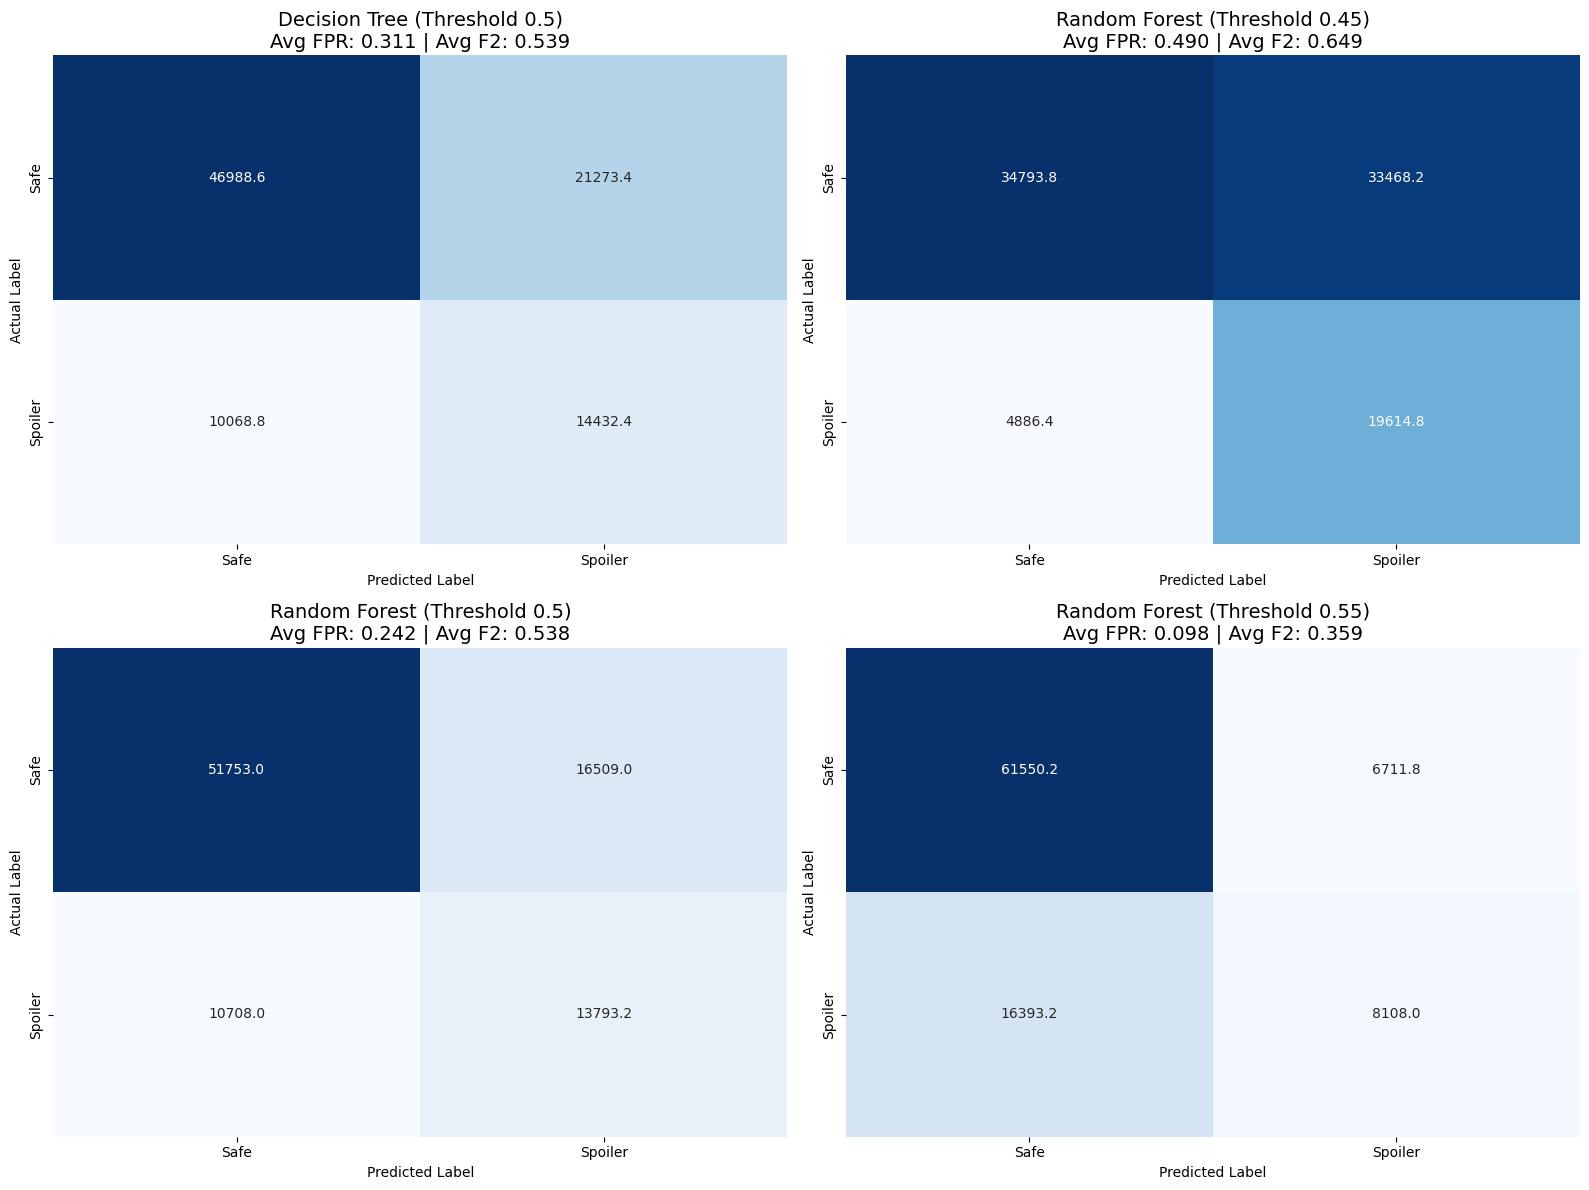

In [38]:
from sklearn.metrics import confusion_matrix, recall_score, fbeta_score, accuracy_score

# 1. Configuration
N_SPLITS = 5  # Assuming 5-fold CV
threshold_dt = 0.5
thresholds_rf = [0.45, 0.5, 0.55]

# Using the best parameters identified previously
dt_params = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
rf_params = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}

# Containers for results
# We store the confusion matrices for every fold to calculate the "Average Matrix"
results = {
    "DT_0.5": {"cm": [], "fpr": [], "f2": []},
    "RF_0.45": {"cm": [], "fpr": [], "f2": []},
    "RF_0.5": {"cm": [], "fpr": [], "f2": []},
    "RF_0.55": {"cm": [], "fpr": [], "f2": []}
}

# 2. Cross-Validation Loop
for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="Calculating Average Metrics"):
    artifacts = load_cv_fold(fold_idx)
    X_train, y_train = artifacts["X_tfidf_train"], np.array(artifacts["y_train"]).ravel()
    X_val, y_val = artifacts["X_tfidf_val"], np.array(artifacts["y_val"]).ravel()

    # Train Models
    dt = DecisionTreeClassifier(**dt_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT).fit(X_train, y_train)
    rf = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1).fit(X_train, y_train)

    # Get Probabilities
    prob_dt = dt.predict_proba(X_val)[:, 1]
    prob_rf = rf.predict_proba(X_val)[:, 1]

    # Helper to store fold metrics
    def add_fold_data(key, y_true, y_prob, t):
        y_pred = (y_prob >= t)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        results[key]["cm"].append(cm)
        results[key]["fpr"].append(fp / (fp + tn))
        results[key]["f2"].append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))

    add_fold_data("DT_0.5", y_val, prob_dt, threshold_dt)
    for t in thresholds_rf:
        add_fold_data(f"RF_{t}", y_val, prob_rf, t)

# 3. Plotting the 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_configs = [
    ("Decision Tree", "DT_0.5", 0.5),
    ("Random Forest", "RF_0.45", 0.45),
    ("Random Forest", "RF_0.5", 0.5),
    ("Random Forest", "RF_0.55", 0.55)
]

for i, (title, key, t) in enumerate(plot_configs):
    # Calculate Average Matrix and Average Metrics
    avg_cm = np.mean(results[key]["cm"], axis=0)
    avg_fpr = np.mean(results[key]["fpr"])
    avg_f2 = np.mean(results[key]["f2"])
    
    # Plotting
    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{title} (Threshold {t})\nAvg FPR: {avg_fpr:.3f} | Avg F2: {avg_f2:.3f}", fontsize=14)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xticklabels(['Safe', 'Spoiler'])
    axes[i].set_yticklabels(['Safe', 'Spoiler'])

plt.tight_layout()
plt.show()

#### 4.6.2 TF-IDF + Lemmatization

##### Baseline Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

if USE_FIXED_BEST_PARAMS and DT_TFIDF_LEMMA_FIXED_PARAMS is not None:
    best_params_dt_lemma = normalize_dt_params(DT_TFIDF_LEMMA_FIXED_PARAMS)
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="DT TF-IDF+Lemma fixed params"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt_lemma["max_depth"],
            min_samples_split=best_params_dt_lemma["min_samples_split"],
            min_samples_leaf=best_params_dt_lemma["min_samples_leaf"],
            ccp_alpha=best_params_dt_lemma["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt_lemma = fixed_cv_fold_details_dt_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt_lemma = []
    cv_fold_details_by_params_dt_lemma = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT TF-IDF+Lemma random search"):
        fold_rows = []
        for fold_idx in tqdm(
            range(1, N_SPLITS + 1),
            desc=f"CV folds {params}",
            leave=False,
        ):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt_lemma[params_key] = fold_df
        cv_summary_rows_dt_lemma.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt_lemma = pd.DataFrame(cv_summary_rows_dt_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt_lemma = normalize_dt_params(cv_results_dt_lemma.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt_lemma}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt_lemma[tuple(best_params_dt_lemma[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt_lemma = cv_fold_details_by_params_dt_lemma[tuple(best_params_dt_lemma[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]
final_model_dt_lemma = DecisionTreeClassifier(
    max_depth=best_params_dt_lemma["max_depth"],
    min_samples_split=best_params_dt_lemma["min_samples_split"],
    min_samples_leaf=best_params_dt_lemma["min_samples_leaf"],
    ccp_alpha=best_params_dt_lemma["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
dt_tfidf_lemma_best_params = dict(best_params_dt_lemma)
dt_tfidf_lemma_model = final_model_dt_lemma

DT TF-IDF+Lemma fixed params:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.683622,0.456011,0.478170,0.540935,0.400683,0.592811,0.656750,1
1,0.696120,0.475242,0.486702,0.550861,0.407583,0.603936,0.664299,2
2,0.694680,0.461842,0.470414,0.530312,0.395889,0.579505,0.668541,3
3,0.688869,0.470244,0.484253,0.543141,0.410140,0.591058,0.658926,4
4,0.687803,0.462965,0.479790,0.542732,0.402074,0.594748,0.655874,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.690219,0.465261,0.479866,0.541596,0.403274,0.592411,0.660878


##### Save Results

In [43]:
# Save the TF-IDF+Lemma Decision Tree CV summary after it has been created.
dt_tfidf_lemma_summary_to_save = globals().get(
    "fixed_cv_summary_dt_lemma",
    globals().get("best_cv_summary_dt_lemma"),
)
if dt_tfidf_lemma_summary_to_save is None:
    raise NameError("Run the TF-IDF+Lemma Decision Tree cell before saving results.")

dt_tfidf_lemma_summary_to_save.to_csv("dt_tfidf_lemma_best_summary.csv", index=False)

##### Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, 
    fbeta_score, precision_score, recall_score, accuracy_score
)

# --- 0. CONFIGURATION ---
RF_THRESHOLD = 0.5

def normalize_rf_params(params_like):
    RF_INT_PARAMS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]
    params = dict(params_like)
    for name in RF_INT_PARAMS:
        if name in params:
            value = params.get(name)
            params[name] = None if value is None or pd.isna(value) else int(value)
    return params

# --- 1. CROSS-VALIDATION LOGIC ---

if USE_FIXED_BEST_PARAMS and globals().get('RF_TF_IDF_LEMMA_FIXED_PARAMS') is not None:
    best_params_rf = normalize_rf_params(RF_TF_IDF_LEMMA_FIXED_PARAMS)
    fold_rows = []
    
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="RF Lemma fixed params"):
        # Load Lemma-specific artifacts
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        
        # Initialize and Train on full fold data
        model = RandomForestClassifier(
            **best_params_rf,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1
        )
        model.fit(X_train, np.array(y_train).ravel())
        
        # Predict
        y_val_prob = model.predict_proba(X_val)[:, 1]
        
        # Calculate Metrics
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)
        
        # Cleanup memory immediately
        del artifacts, model, X_train, X_val
        gc.collect()

    # --- 2. OUTPUT DISPLAY ---
    fixed_cv_fold_details_rf = pd.DataFrame(fold_rows)
    fixed_cv_summary_rf = fixed_cv_fold_details_rf[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    
    print(f"Using fixed params: {best_params_rf} (full search skipped)")
    display(fixed_cv_fold_details_rf.rename(columns={"average_precision": "pr-auc"}))
    display(fixed_cv_summary_rf.rename(columns={"average_precision": "pr-auc"}))

else:
    # --- 3. RANDOM SEARCH LOGIC ---
    RF_PARAM_GRID = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    RF_RANDOM_SEARCH_ITER = 5
    
    cv_summary_rows_rf = []
    sampled_param_grid = list(ParameterSampler(RF_PARAM_GRID, n_iter=RF_RANDOM_SEARCH_ITER, random_state=RANDOM_STATE))

    for params in tqdm(sampled_param_grid, desc="RF Lemma random search"):
        fold_rows = []
        for fold_idx in range(1, N_SPLITS + 1):
            artifacts = load_cv_fold(fold_idx)
            X_train, y_train = artifacts["X_tfidf_lemma_train"], artifacts["y_train"]
            X_val, y_val = artifacts["X_tfidf_lemma_val"], artifacts["y_val"]
            
            model = RandomForestClassifier(**params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
            model.fit(X_train, np.array(y_train).ravel())
            y_val_prob = model.predict_proba(X_val)[:, 1]
            
            fold_rows.append({
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
                "fold": fold_idx,
            })
            del artifacts, model
            gc.collect()
        
        fold_df = pd.DataFrame(fold_rows)
        cv_summary_rows_rf.append({
            **params,
            "mean_auc": fold_df["auc"].mean(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_rf = pd.DataFrame(cv_summary_rows_rf).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary (ranked by mean AUC):")
    display(cv_results_rf.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_rf = normalize_rf_params(cv_results_rf.loc[0, ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]])

# --- 4. FINAL MODEL TRAINING ON FULL DATA ---
artifacts_full = load_full_train_test()
X_train_full = artifacts_full["X_tfidf_lemma_train_full"]
y_train_full = np.array(artifacts_full["y_train_full"]).ravel()

final_model_rf_lemma = RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
final_model_rf_lemma.fit(X_train_full, y_train_full)

rf_tfidf_lemma_model = final_model_rf_lemma

RF Lemma fixed params:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2} (full search skipped)


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.726443,0.498400,0.498096,0.529365,0.453453,0.552488,0.704622,1
1,0.732430,0.505855,0.506338,0.542804,0.455354,0.570179,0.707008,2
2,0.735210,0.499128,0.499264,0.541180,0.442182,0.573267,0.707886,3
3,0.724807,0.501607,0.504082,0.540411,0.453295,0.567686,0.697399,4
4,0.722741,0.493284,0.495492,0.525474,0.452466,0.547561,0.702477,5


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.728326,0.499655,0.500654,0.535847,0.45135,0.562236,0.703878


#### 4.6.3 BERT Embeddings

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

if USE_FIXED_BEST_PARAMS and DT_BERT_FIXED_PARAMS is not None:
    best_params_dt_bert = normalize_dt_params(DT_BERT_FIXED_PARAMS)
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc="DT BERT fixed params",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt_bert["max_depth"],
            min_samples_split=best_params_dt_bert["min_samples_split"],
            min_samples_leaf=best_params_dt_bert["min_samples_leaf"],
            ccp_alpha=best_params_dt_bert["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt_bert = fixed_cv_fold_details_dt_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt_bert = []
    cv_fold_details_by_params_dt_bert = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT BERT random search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds {params}",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt_bert[params_key] = fold_df
        cv_summary_rows_dt_bert.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt_bert = pd.DataFrame(cv_summary_rows_dt_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt_bert = normalize_dt_params(cv_results_dt_bert.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt_bert}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt_bert[tuple(best_params_dt_bert[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt_bert = cv_fold_details_by_params_dt_bert[tuple(best_params_dt_bert[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt_bert.rename(columns={"average_precision": "pr-auc"}))

final_model_dt_bert = DecisionTreeClassifier(
    max_depth=best_params_dt_bert["max_depth"],
    min_samples_split=best_params_dt_bert["min_samples_split"],
    min_samples_leaf=best_params_dt_bert["min_samples_leaf"],
    ccp_alpha=best_params_dt_bert["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 5)
dt_bert_best_params = dict(best_params_dt_bert)
dt_bert_model = final_model_dt_bert

DT BERT fixed params:   0%|          | 0/5 [00:00<?, ?it/s]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.654017,0.380034,0.460652,0.564084,0.352827,0.663385,0.587894,1
1,0.664565,0.388064,0.471320,0.591533,0.352071,0.712724,0.578639,2
2,0.655104,0.363175,0.452548,0.558849,0.343614,0.662611,0.592754,3
3,0.651672,0.384114,0.468349,0.577936,0.355879,0.684752,0.578841,4
4,0.653694,0.379131,0.466337,0.577183,0.353264,0.685869,0.581143,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.65581,0.378904,0.463841,0.573917,0.351531,0.681868,0.583854


#### 4.6.4 Cross-Validation Summary

In [46]:
def summarize_dt_cv_metrics():
    summary_candidates = [
        ("TF-IDF", globals().get("fixed_cv_summary_dt", globals().get("best_cv_summary_dt"))),
        ("TF-IDF+Lemma", globals().get("fixed_cv_summary_dt_lemma", globals().get("best_cv_summary_dt_lemma"))),
        ("BERT", globals().get("fixed_cv_summary_dt_bert", globals().get("best_cv_summary_dt_bert"))),
    ]

    rows = []
    for feature, summary in summary_candidates:
        if summary is None:
            continue

        if isinstance(summary, pd.DataFrame):
            metrics = summary.iloc[0].to_dict()
        else:
            metrics = dict(summary)

        pr_auc = metrics.get("average_precision", metrics.get("pr-auc"))
        rows.append(
            {
                "feature": feature,
                "auc": metrics.get("auc"),
                "pr-auc": pr_auc,
                "f1": metrics.get("f1"),
                "f2": metrics.get("f2"),
                "precision": metrics.get("precision"),
                "recall": metrics.get("recall"),
                "accuracy": metrics.get("accuracy"),
            }
        )

    if not rows:
        raise ValueError("No Decision Tree cross-validation summary variables found. Run the Decision Tree training cells first.")

    return pd.DataFrame(rows)

dt_train_metrics_df = summarize_dt_cv_metrics()
print("Decision Tree cross-validation metrics on the training set:")
display(
    dt_train_metrics_df[["feature", "auc", "pr-auc", "f1", "f2", "precision", "recall", "accuracy"]]
        .round(6)
)

Decision Tree cross-validation metrics on the training set:


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.688269,0.462524,0.479282,0.539428,0.404279,0.588760,0.662239
1,TF-IDF+Lemma,0.690219,0.465261,0.479866,0.541596,0.403274,0.592411,0.660878
2,BERT,0.655810,0.378904,0.463841,0.573917,0.351531,0.681868,0.583854


### 4.7 Naive Bayes

#### 4.7.1 TF-IDF

##### 4.7.1.1 Alpha Tuning

In [18]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB

NB_METRIC_COLUMNS = ["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]

def summarize_nb_metrics(df):
    return df[NB_METRIC_COLUMNS].mean().to_frame().T

def compute_nb_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

def evaluate_nb_tfidf_artifacts(alpha, threshold=0.5):
    rows = []
    for artifact_name in ARTIFACT_DIRS:
        artifacts = load_cv_fold(artifact_name=artifact_name)
        model = MultinomialNB(alpha=alpha)
        model.fit(artifacts["X_tfidf_train"], artifacts["y_train"])
        y_val_prob = model.predict_proba(artifacts["X_tfidf_val"])[:, 1]
        rows.append({"artifact_dir": artifact_name, **compute_nb_metrics(artifacts["y_val"], y_val_prob, threshold=threshold)})
    return pd.DataFrame(rows)

def evaluate_nb_sbert_artifacts(var_smoothing, threshold=0.5):
    rows = []
    for artifact_name in ARTIFACT_DIRS:
        artifacts = load_sbert_artifact_validation_splits(artifact_name=artifact_name)
        model = GaussianNB(var_smoothing=var_smoothing)
        model.fit(artifacts["X_sbert_train"], artifacts["y_sbert_train"])
        y_val_prob_window = model.predict_proba(artifacts["X_sbert_val"])[:, 1]
        y_val_true_review, y_val_prob_review = aggregate_review_probs_topk(
            y_val_prob_window,
            artifacts["review_ids_val"],
            artifacts["review_label_map_val"],
            k=NB_SBERT_TOPK,
        )
        rows.append({"artifact_dir": artifact_name, **compute_nb_metrics(y_val_true_review, y_val_prob_review, threshold=threshold)})
    return pd.DataFrame(rows)

if USE_FIXED_BEST_PARAMS and NB_TFIDF_FIXED_ALPHA is not None:
    best_alpha_nb = float(NB_TFIDF_FIXED_ALPHA)
    artifact_validation_metrics_nb_fixed_alpha = evaluate_nb_tfidf_artifacts(best_alpha_nb)
    artifact_validation_summary_nb_fixed_alpha_by_artifact = artifact_validation_metrics_nb_fixed_alpha.copy()
    artifact_validation_summary_nb_fixed_alpha = summarize_nb_metrics(artifact_validation_metrics_nb_fixed_alpha)

    print(f"Using fixed alpha: {best_alpha_nb} (full search skipped)")
    print("Validation metrics by artifact set:")
    display(artifact_validation_metrics_nb_fixed_alpha.rename(columns={"average_precision": "pr-auc"}))
    print("Average metrics across artifact sets:")
    display(artifact_validation_summary_nb_fixed_alpha.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_selected_alpha = artifact_validation_summary_nb_fixed_alpha

else:
    artifact_validation_search_rows_nb_alpha = []
    artifact_validation_summary_nb_by_alpha_and_artifact = {}

    for alpha in tqdm(NB_ALPHA_GRID, desc="NB TF-IDF alpha search"):
        per_artifact_df = evaluate_nb_tfidf_artifacts(alpha).assign(alpha=alpha)
        artifact_validation_summary_nb_by_alpha_and_artifact[alpha] = per_artifact_df
        overall_summary = summarize_nb_metrics(per_artifact_df).iloc[0]

        artifact_validation_search_rows_nb_alpha.append(
            {
                "alpha": alpha,
                "mean_auc": overall_summary["auc"],
                "mean_average_precision": overall_summary["average_precision"],
                "mean_f1": overall_summary["f1"],
                "mean_f2": overall_summary["f2"],
                "mean_precision": overall_summary["precision"],
                "mean_recall": overall_summary["recall"],
                "mean_accuracy": overall_summary["accuracy"],
            }
        )

    artifact_validation_results_nb_alpha = (
        pd.DataFrame(artifact_validation_search_rows_nb_alpha)
        .sort_values("mean_auc", ascending=False)
        .reset_index(drop=True)
    )

    print("Validation summary across alpha values (ranked by mean AUC across artifact sets):")
    display(artifact_validation_results_nb_alpha.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_alpha_nb = float(artifact_validation_results_nb_alpha.loc[0, "alpha"])
    print(f"\nBest alpha by validation mean AUC: {best_alpha_nb}")

    print("Validation metrics by artifact set for best alpha:")
    display(
        artifact_validation_summary_nb_by_alpha_and_artifact[best_alpha_nb]
        .rename(columns={"average_precision": "pr-auc"})
    )

    artifact_validation_summary_nb_best_alpha = summarize_nb_metrics(artifact_validation_summary_nb_by_alpha_and_artifact[best_alpha_nb])
    print("Average validation metrics across artifact sets for best alpha:")
    display(artifact_validation_summary_nb_best_alpha.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_selected_alpha = artifact_validation_summary_nb_best_alpha

nb_tfidf_models = {}

for artifact_name in ARTIFACT_DIRS:
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    X_train_full = artifacts["X_tfidf_train_full"]
    y_train_full = artifacts["y_train_full"]

    final_model_nb = MultinomialNB(alpha=best_alpha_nb)
    final_model_nb.fit(X_train_full, y_train_full)

    nb_tfidf_models[artifact_name] = final_model_nb

# Keep model(s) and selected hyperparameter available for model evaluation (section 5)
nb_tfidf_best_alpha = best_alpha_nb
print(f"Stored Naive Bayes TF-IDF models for: {list(nb_tfidf_models.keys())}")
print(f"Selected alpha: {nb_tfidf_best_alpha}")

NB TF-IDF alpha search:   0%|          | 0/3 [00:00<?, ?it/s]

CV folds (alpha=0.005):   0%|          | 0/5 [00:00<?, ?it/s]

CV folds (alpha=0.01):   0%|          | 0/5 [00:00<?, ?it/s]

CV folds (alpha=0.05):   0%|          | 0/5 [00:00<?, ?it/s]

CV summary across alpha values (ranked by mean AUC):


,alpha,mean_auc,std_auc,mean_pr-auc,mean_f1,mean_f2,mean_precision,mean_recall,mean_accuracy
0,0.005,0.723519,0.002673,0.500631,0.492522,0.646908,0.352373,0.817826,0.554858
1,0.010,0.723518,0.002673,0.500625,0.492524,0.646906,0.352376,0.817818,0.554864
2,0.050,0.723510,0.002670,0.500578,0.492462,0.646879,0.352305,0.817859,0.554733



Best alpha by CV mean AUC: 0.005
Fold-by-fold metrics for best alpha:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.721496,0.500368,0.492139,0.646845,0.351876,0.818344,0.553341,1
1,0.727680,0.506044,0.495876,0.649069,0.355884,0.817421,0.560023,2
2,0.724748,0.502774,0.493840,0.648139,0.353557,0.818666,0.555943,3
3,0.721816,0.488170,0.490654,0.647988,0.349302,0.824174,0.548904,4
4,0.721855,0.505797,0.490103,0.642501,0.351246,0.810523,0.556079,5


Average fold metrics for best alpha:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.723519,0.500631,0.492522,0.646908,0.352373,0.817826,0.554858


##### 4.7.1.2 Threshold Tuning

In [23]:
if "best_alpha_nb" not in globals():
    raise ValueError("Run the Naive Bayes alpha-tuning cell first so best_alpha_nb is available.")

if USE_FIXED_BEST_PARAMS and NB_TFIDF_FIXED_THRESHOLD is not None:
    best_threshold_nb = float(NB_TFIDF_FIXED_THRESHOLD)
    artifact_validation_metrics_nb_fixed_threshold = evaluate_nb_tfidf_artifacts(best_alpha_nb, threshold=best_threshold_nb)
    artifact_validation_summary_nb_fixed_threshold_by_artifact = artifact_validation_metrics_nb_fixed_threshold.copy()
    artifact_validation_summary_nb_fixed_threshold = summarize_nb_metrics(artifact_validation_metrics_nb_fixed_threshold)

    print(f"Using fixed threshold: {best_threshold_nb} (full search skipped)")
    print("Validation metrics by artifact set:")
    display(artifact_validation_metrics_nb_fixed_threshold.rename(columns={"average_precision": "pr-auc"}))
    print("Average metrics across artifact sets:")
    display(artifact_validation_summary_nb_fixed_threshold.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_selected_threshold = artifact_validation_summary_nb_fixed_threshold

else:
    artifact_validation_search_rows_nb_threshold = []
    artifact_validation_summary_nb_by_threshold_and_artifact = {}

    for threshold in tqdm(NB_THRESHOLD_GRID, desc="NB TF-IDF threshold search"):
        per_artifact_df = evaluate_nb_tfidf_artifacts(best_alpha_nb, threshold=threshold).assign(threshold=threshold)
        artifact_validation_summary_nb_by_threshold_and_artifact[threshold] = per_artifact_df
        overall_summary = summarize_nb_metrics(per_artifact_df).iloc[0]

        artifact_validation_search_rows_nb_threshold.append(
            {
                "threshold": threshold,
                "mean_auc": overall_summary["auc"],
                "std_auc": per_artifact_df["auc"].std(),
                "mean_average_precision": overall_summary["average_precision"],
                "mean_f1": overall_summary["f1"],
                "mean_f2": overall_summary["f2"],
                "mean_precision": overall_summary["precision"],
                "mean_recall": overall_summary["recall"],
                "mean_accuracy": overall_summary["accuracy"],
            }
        )

    artifact_validation_results_nb_threshold = (
        pd.DataFrame(artifact_validation_search_rows_nb_threshold)
        .sort_values("mean_f2", ascending=False)
        .reset_index(drop=True)
    )

    print("Validation summary across threshold values (ranked by mean F2 across artifact sets):")
    display(artifact_validation_results_nb_threshold.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_threshold_nb = float(artifact_validation_results_nb_threshold.loc[0, "threshold"])
    print(f"\nBest threshold by validation mean F2: {best_threshold_nb}")

    print("Validation metrics by artifact set for best threshold:")
    display(
        artifact_validation_summary_nb_by_threshold_and_artifact[best_threshold_nb]
        .rename(columns={"average_precision": "pr-auc"})
    )

    artifact_validation_summary_nb_best_threshold = summarize_nb_metrics(artifact_validation_summary_nb_by_threshold_and_artifact[best_threshold_nb])
    print("Average validation metrics across artifact sets for best threshold:")
    display(artifact_validation_summary_nb_best_threshold.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_selected_threshold = artifact_validation_summary_nb_best_threshold

nb_tfidf_best_threshold = best_threshold_nb
print(f"Selected Naive Bayes TF-IDF threshold: {nb_tfidf_best_threshold}")

NB TF-IDF threshold search:   0%|          | 0/10 [00:00<?, ?it/s]

CV folds (threshold=0.05):   0%|          | 0/5 [00:00<?, ?it/s]

CV folds (threshold=0.1):   0%|          | 0/5 [00:00<?, ?it/s]

CV folds (threshold=0.15):   0%|          | 0/5 [00:00<?, ?it/s]

CV folds (threshold=0.2):   0%|          | 0/5 [00:00<?, ?it/s]

...


Best threshold by CV mean F2: 0.15
Fold-by-fold metrics for best threshold:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.721496,0.500368,0.456607,0.655922,0.303101,0.925150,0.417672,1
1,0.727680,0.506044,0.459103,0.658970,0.304950,0.928423,0.420878,2
2,0.724748,0.502774,0.458822,0.660541,0.304062,0.934416,0.416734,3
3,0.721816,0.488170,0.456394,0.658133,0.302070,0.933106,0.414010,4
4,0.721855,0.505797,0.455353,0.653255,0.302578,0.919740,0.420871,5


Average fold metrics for best threshold:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.723519,0.500631,0.457256,0.657364,0.303352,0.928167,0.418033


Selected Naive Bayes TF-IDF threshold: 0.15


#### 4.7.2 SBERT Windows

##### 4.7.2.1 Variance Smoothing Tuning

In [ ]:
if USE_FIXED_BEST_PARAMS and NB_SBERT_FIXED_VAR_SMOOTHING is not None:
    best_var_smoothing_nb_sbert = float(NB_SBERT_FIXED_VAR_SMOOTHING)
    artifact_validation_metrics_nb_sbert_fixed_var_smoothing = evaluate_nb_sbert_artifacts(best_var_smoothing_nb_sbert)
    artifact_validation_summary_nb_sbert_fixed_var_smoothing_by_artifact = artifact_validation_metrics_nb_sbert_fixed_var_smoothing.copy()
    artifact_validation_summary_nb_sbert_fixed_var_smoothing = summarize_nb_metrics(artifact_validation_metrics_nb_sbert_fixed_var_smoothing)

    print(f"Using fixed var_smoothing: {best_var_smoothing_nb_sbert:.0e} (full search skipped)")
    print("Validation metrics by artifact set:")
    display(artifact_validation_metrics_nb_sbert_fixed_var_smoothing.rename(columns={"average_precision": "pr-auc"}))
    print("Average validation metrics across artifact sets:")
    display(artifact_validation_summary_nb_sbert_fixed_var_smoothing.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_sbert_selected_var_smoothing = artifact_validation_summary_nb_sbert_fixed_var_smoothing

else:
    artifact_validation_search_rows_nb_sbert_var_smoothing = []
    artifact_validation_summary_nb_sbert_by_var_smoothing_and_artifact = {}

    for var_smoothing in tqdm(NB_SBERT_VAR_SMOOTHING_GRID, desc="NB SBERT var_smoothing search"):
        per_artifact_df = evaluate_nb_sbert_artifacts(var_smoothing).assign(var_smoothing=var_smoothing)
        artifact_validation_summary_nb_sbert_by_var_smoothing_and_artifact[var_smoothing] = per_artifact_df
        overall_summary = summarize_nb_metrics(per_artifact_df).iloc[0]

        artifact_validation_search_rows_nb_sbert_var_smoothing.append(
            {
                "var_smoothing": var_smoothing,
                "mean_auc": overall_summary["auc"],
                "mean_average_precision": overall_summary["average_precision"],
                "mean_f1": overall_summary["f1"],
                "mean_f2": overall_summary["f2"],
                "mean_precision": overall_summary["precision"],
                "mean_recall": overall_summary["recall"],
                "mean_accuracy": overall_summary["accuracy"],
            }
        )

    artifact_validation_results_nb_sbert_var_smoothing = (
        pd.DataFrame(artifact_validation_search_rows_nb_sbert_var_smoothing)
        .sort_values("mean_auc", ascending=False)
        .reset_index(drop=True)
    )

    print("Validation summary across var_smoothing values (ranked by mean AUC across artifact sets):")
    display(artifact_validation_results_nb_sbert_var_smoothing.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_var_smoothing_nb_sbert = float(artifact_validation_results_nb_sbert_var_smoothing.loc[0, "var_smoothing"])
    print(f"\nBest var_smoothing by validation mean AUC: {best_var_smoothing_nb_sbert:.0e}")

    print("Validation metrics by artifact set for best var_smoothing:")
    display(
        artifact_validation_summary_nb_sbert_by_var_smoothing_and_artifact[best_var_smoothing_nb_sbert]
        .rename(columns={"average_precision": "pr-auc"})
    )

    artifact_validation_summary_nb_sbert_best_var_smoothing = summarize_nb_metrics(artifact_validation_summary_nb_sbert_by_var_smoothing_and_artifact[best_var_smoothing_nb_sbert])
    print("Average validation metrics across artifact sets for best var_smoothing:")
    display(artifact_validation_summary_nb_sbert_best_var_smoothing.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_sbert_selected_var_smoothing = artifact_validation_summary_nb_sbert_best_var_smoothing

nb_sbert_models = {}

for artifact_name in ARTIFACT_DIRS:
    artifacts = load_sbert_artifact_fulltrain_test_splits(artifact_name=artifact_name)
    X_train_full = artifacts["X_sbert_train_full"]
    y_train_full = artifacts["y_sbert_train_full"]

    final_model_nb_sbert = GaussianNB(var_smoothing=best_var_smoothing_nb_sbert)
    final_model_nb_sbert.fit(X_train_full, y_train_full)

    nb_sbert_models[artifact_name] = final_model_nb_sbert

nb_sbert_best_var_smoothing = best_var_smoothing_nb_sbert
print(f"Stored GaussianNB SBERT window models for: {list(nb_sbert_models.keys())}")
print(f"Selected var_smoothing: {nb_sbert_best_var_smoothing:.0e}")

##### 4.7.2.2 Threshold Tuning

In [ ]:
if "best_var_smoothing_nb_sbert" not in globals():
    raise ValueError(
        "Run the SBERT variance-smoothing tuning cell first so best_var_smoothing_nb_sbert is available."
    )

if USE_FIXED_BEST_PARAMS and NB_SBERT_FIXED_THRESHOLD is not None:
    best_threshold_nb_sbert = float(NB_SBERT_FIXED_THRESHOLD)
    artifact_validation_metrics_nb_sbert_fixed_threshold = evaluate_nb_sbert_artifacts(best_var_smoothing_nb_sbert, threshold=best_threshold_nb_sbert)
    artifact_validation_summary_nb_sbert_fixed_threshold_by_artifact = artifact_validation_metrics_nb_sbert_fixed_threshold.copy()
    artifact_validation_summary_nb_sbert_fixed_threshold = summarize_nb_metrics(artifact_validation_metrics_nb_sbert_fixed_threshold)

    print(f"Using fixed threshold: {best_threshold_nb_sbert} (full search skipped)")
    print("Validation metrics by artifact set:")
    display(artifact_validation_metrics_nb_sbert_fixed_threshold.rename(columns={"average_precision": "pr-auc"}))
    print("Average validation metrics across artifact sets:")
    display(artifact_validation_summary_nb_sbert_fixed_threshold.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_sbert_selected_threshold = artifact_validation_summary_nb_sbert_fixed_threshold

else:
    artifact_validation_search_rows_nb_sbert_threshold = []
    artifact_validation_summary_nb_sbert_by_threshold_and_artifact = {}

    for threshold in tqdm(NB_SBERT_THRESHOLD_GRID, desc="NB SBERT threshold search"):
        per_artifact_df = evaluate_nb_sbert_artifacts(best_var_smoothing_nb_sbert, threshold=threshold).assign(threshold=threshold)
        artifact_validation_summary_nb_sbert_by_threshold_and_artifact[threshold] = per_artifact_df
        overall_summary = summarize_nb_metrics(per_artifact_df).iloc[0]

        artifact_validation_search_rows_nb_sbert_threshold.append(
            {
                "threshold": threshold,
                "mean_auc": overall_summary["auc"],
                "std_auc": per_artifact_df["auc"].std(),
                "mean_average_precision": overall_summary["average_precision"],
                "mean_f1": overall_summary["f1"],
                "mean_f2": overall_summary["f2"],
                "mean_precision": overall_summary["precision"],
                "mean_recall": overall_summary["recall"],
                "mean_accuracy": overall_summary["accuracy"],
            }
        )

    artifact_validation_results_nb_sbert_threshold = (
        pd.DataFrame(artifact_validation_search_rows_nb_sbert_threshold)
        .sort_values("mean_f2", ascending=False)
        .reset_index(drop=True)
    )

    print("Validation summary across threshold values (ranked by mean F2 across artifact sets):")
    display(artifact_validation_results_nb_sbert_threshold.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_threshold_nb_sbert = float(artifact_validation_results_nb_sbert_threshold.loc[0, "threshold"])
    print(f"\nBest threshold by validation mean F2: {best_threshold_nb_sbert}")

    print("Validation metrics by artifact set for best threshold:")
    display(
        artifact_validation_summary_nb_sbert_by_threshold_and_artifact[best_threshold_nb_sbert]
        .rename(columns={"average_precision": "pr-auc"})
    )

    artifact_validation_summary_nb_sbert_best_threshold = summarize_nb_metrics(artifact_validation_summary_nb_sbert_by_threshold_and_artifact[best_threshold_nb_sbert])
    print("Average validation metrics across artifact sets for best threshold:")
    display(artifact_validation_summary_nb_sbert_best_threshold.rename(columns={"average_precision": "pr-auc"}))
    artifact_validation_summary_nb_sbert_selected_threshold = artifact_validation_summary_nb_sbert_best_threshold

nb_sbert_best_threshold = best_threshold_nb_sbert
print(f"Selected Naive Bayes SBERT threshold: {nb_sbert_best_threshold}")

### 4.7.3 Model Selection Summary

In [14]:
nb_train_metrics_df = pd.DataFrame([
    {"feature": "TF-IDF", **artifact_validation_summary_nb_selected_threshold.iloc[0].to_dict()},
    {"feature": "SBERT Windows", **artifact_validation_summary_nb_sbert_selected_threshold.iloc[0].to_dict()},
]).rename(columns={"average_precision": "pr-auc"})

print("Naive Bayes model-selection metrics:")
display(
    nb_train_metrics_df[["feature", "auc", "pr-auc", "f1", "f2", "precision", "recall", "accuracy"]]
        .round(6)
)

Naive Bayes cross-validation metrics on the training set:


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.723518,0.500625,0.24046,0.173551,0.675383,0.146401,0.755876


## 5. Final Test Set Evaluation

This section reports held-out test performance after hyperparameter tuning and final refitting are complete. Results are compared across the three feature representations: TF-IDF, TF-IDF + lemmatization, and BERT embeddings.

### 5.1 Logistic Regression

In [47]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_tfidf = logreg_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_tfidf = compute_metrics(y_test, y_test_prob_tfidf)

# TF-IDF + Lemma
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_lemma = logreg_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_lemma = compute_metrics(y_test, y_test_prob_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_bert = logreg_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_bert = compute_metrics(y_test, y_test_prob_bert)

# Compare test results
test_metrics_df = pd.DataFrame([
    {"feature": "TF-IDF", **test_metrics_tfidf},
    {"feature": "TF-IDF+Lemma", **test_metrics_lemma},
    {"feature": "BERT", **test_metrics_bert}
])
print("\nFinal held-out test metrics (Logistic Regression):")
display(
    test_metrics_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]]
        .rename(columns={"average_precision": "pr-auc"})
)


Final held-out test metrics (Logistic Regression):


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.769532,0.560100,0.547740,0.604820,0.473294,0.649977,0.722884
1,TF-IDF+Lemma,0.768896,0.560012,0.544281,0.600265,0.471058,0.644457,0.721376
2,BERT,0.726797,0.472879,0.505393,0.591910,0.406392,0.668165,0.662352


### 5.2 Support Vector Machine

In [48]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_svm_tfidf = svm_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_svm_tfidf = compute_metrics(y_test, y_test_prob_svm_tfidf)

# TF-IDF + Lemma
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_svm_lemma = svm_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_svm_lemma = compute_metrics(y_test, y_test_prob_svm_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_svm_bert = svm_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_svm_bert = compute_metrics(y_test, y_test_prob_svm_bert)

# Combine results
test_metrics_svm_df = pd.DataFrame([
    {"feature": "TF-IDF", **test_metrics_svm_tfidf},
    {"feature": "TF-IDF+Lemma", **test_metrics_svm_lemma},
    {"feature": "BERT", **test_metrics_svm_bert}
])
print("\nFinal held-out test metrics (SVM):")
display(
    test_metrics_svm_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]]
        .rename(columns={"average_precision": "pr-auc"})
)


Final held-out test metrics (SVM):


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.769424,0.557291,0.395962,0.317939,0.669985,0.281023,0.778638
1,TF-IDF+Lemma,0.768827,0.557438,0.392963,0.315019,0.668736,0.278228,0.778071
2,BERT,0.727075,0.472891,0.287527,0.220461,0.583234,0.190793,0.755881


### 5.3 Decision Tree and Random Forest

In [ ]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_dt_tfidf = dt_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_dt_tfidf = compute_metrics(y_test, y_test_prob_dt_tfidf)

# Random Forest - TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_rf_tfidf = rf_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_rf_tfidf = compute_metrics(y_test, y_test_prob_rf_tfidf)

# TF-IDF + Lemmatization
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_dt_tfidf_lemma = dt_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_dt_lemma = compute_metrics(y_test, y_test_prob_dt_tfidf_lemma)

# Random Forest - TF-IDF + Lemmatization
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test = artifacts["y_test"]
y_test_prob_rf_lemma = rf_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_rf_lemma = compute_metrics(y_test, y_test_prob_rf_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_dt_bert = dt_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_dt_bert = compute_metrics(y_test, y_test_prob_dt_bert)

# Combine results
test_metrics_dt_df = pd.DataFrame([
    {"feature": "Decision Tree - TF-IDF", **test_metrics_dt_tfidf},
    {"feature": "Random Forest - TF-IDF", **test_metrics_rf_tfidf},
    {"feature": "Decision Tree - TF-IDF+Lemma", **test_metrics_dt_lemma},
    {"feature": "Random Forest - TF-IDF+Lemma", **test_metrics_rf_lemma},
    {"feature": "Decision Tree - BERT", **test_metrics_dt_bert}
])
print("\nFinal held-out test metrics (Decision Tree + Random Forest):")
display(
    test_metrics_dt_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]]
        .rename(columns={"average_precision": "pr-auc"})
)


Final held-out test metrics (Decision Tree):


,feature,auc,pr-auc,f1,f2,precision,recall,accuracy
0,TF-IDF,0.692569,0.462524,0.478271,0.546710,0.395709,0.604366,0.659574
1,Random Forest - TF-IDF,0.735634,0.497496,0.503930,0.546191,0.446368,0.578536,0.705928
2,TF-IDF+Lemma,0.695331,0.465628,0.474816,0.530535,0.404084,0.575563,0.671277
3,Random Forest - TF-IDF+Lemma,0.736623,0.501577,0.505590,0.549051,0.446664,0.582428,0.705910
4,BERT,0.664972,0.373711,0.457932,0.547098,0.360113,0.628711,0.615715


### 5.4 Naive Bayes

In [ ]:
artifact_test_rows_nb = []

for artifact_name in ARTIFACT_DIRS:
    artifacts = load_full_train_test(artifact_name=artifact_name, use_fulltrain=True)
    y_test_prob_nb = nb_tfidf_models[artifact_name].predict_proba(artifacts["X_tfidf_test"])[:, 1]
    artifact_test_rows_nb.append(
        {
            "artifact_dir": artifact_name,
            "feature": "TF-IDF",
            "alpha": nb_tfidf_best_alpha,
            "var_smoothing": np.nan,
            "threshold": nb_tfidf_best_threshold,
            **compute_nb_metrics(artifacts["y_test"], y_test_prob_nb, threshold=nb_tfidf_best_threshold),
        }
    )

for artifact_name in ARTIFACT_DIRS:
    artifacts = load_sbert_artifact_fulltrain_test_splits(artifact_name=artifact_name)
    y_test_prob_window = nb_sbert_models[artifact_name].predict_proba(artifacts["X_sbert_test"])[:, 1]
    y_test_review_true, y_test_review_prob = aggregate_review_probs_topk(
        y_test_prob_window,
        artifacts["review_ids_test"],
        artifacts["review_label_map_test"],
        k=NB_SBERT_TOPK,
    )
    artifact_test_rows_nb.append(
        {
            "artifact_dir": artifact_name,
            "feature": "SBERT Windows",
            "alpha": np.nan,
            "var_smoothing": nb_sbert_best_var_smoothing,
            "threshold": nb_sbert_best_threshold,
            **compute_nb_metrics(y_test_review_true, y_test_review_prob, threshold=nb_sbert_best_threshold),
        }
    )

test_metrics_nb_df = pd.DataFrame(artifact_test_rows_nb)
print("\nFinal held-out test metrics by artifact set (Naive Bayes):")
display(
    test_metrics_nb_df[
        [
            "artifact_dir",
            "feature",
            "alpha",
            "var_smoothing",
            "threshold",
            "auc",
            "average_precision",
            "f1",
            "f2",
            "precision",
            "recall",
            "accuracy",
        ]
    ].rename(columns={"average_precision": "pr-auc"})
)

test_metrics_nb_avg = pd.DataFrame([
    {
        "feature": "TF-IDF",
        "alpha": nb_tfidf_best_alpha,
        "var_smoothing": np.nan,
        "threshold": nb_tfidf_best_threshold,
        **summarize_nb_metrics(test_metrics_nb_df[test_metrics_nb_df["feature"] == "TF-IDF"]).iloc[0].to_dict(),
    },
    {
        "feature": "SBERT Windows",
        "alpha": np.nan,
        "var_smoothing": nb_sbert_best_var_smoothing,
        "threshold": nb_sbert_best_threshold,
        **summarize_nb_metrics(test_metrics_nb_df[test_metrics_nb_df["feature"] == "SBERT Windows"]).iloc[0].to_dict(),
    },
])

print("\nAverage held-out test metrics by feature (Naive Bayes):")
display(
    test_metrics_nb_avg[
        [
            "feature",
            "alpha",
            "var_smoothing",
            "threshold",
            "auc",
            "average_precision",
            "f1",
            "f2",
            "precision",
            "recall",
            "accuracy",
        ]
    ].rename(columns={"average_precision": "pr-auc"})
)